#### Dataset

In [2]:
# Name: news_data.csv, sample_news.txt
# Location: https://mitu.co.in/dataset

##### Download the dataset and save in your current working directory

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

#### Load the dataset

In [5]:
df = pd.read_csv('news_data.csv')

In [6]:
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [7]:
df.shape

(9900, 2)

In [8]:
df.columns

Index(['Text', 'label'], dtype='object')

#### Separate the input and output data

In [10]:
features = df['Text']  # input data 
labels = df['label']   # output data

In [11]:
features

0        Top Trump Surrogate BRUTALLY Stabs Him In The...
1       U.S. conservative leader optimistic of common ...
2       Trump proposes U.S. tax overhaul, stirs concer...
3        Court Forces Ohio To Allow Millions Of Illega...
4       Democrats say Trump agrees to work on immigrat...
                              ...                        
9895     Wikileaks Admits To Screwing Up IMMENSELY Wit...
9896    Trump consults Republican senators on Fed chie...
9897    Trump lawyers say judge lacks jurisdiction for...
9898     WATCH: Right-Wing Pastor Falsely Credits Trum...
9899     Sean Spicer HILARIOUSLY Branded As Chickensh*...
Name: Text, Length: 9900, dtype: object

In [12]:
labels

0       Fake
1       Real
2       Real
3       Fake
4       Real
        ... 
9895    Fake
9896    Real
9897    Real
9898    Fake
9899    Fake
Name: label, Length: 9900, dtype: object

In [13]:
set(labels)

{'Fake', 'Real'}

In [14]:
import seaborn as sns

<Axes: xlabel='label', ylabel='count'>

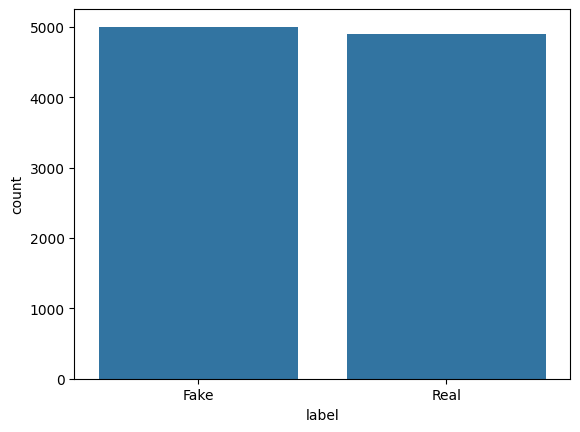

In [15]:
sns.countplot(x = labels)

In [16]:
labels.value_counts()

label
Fake    5000
Real    4900
Name: count, dtype: int64

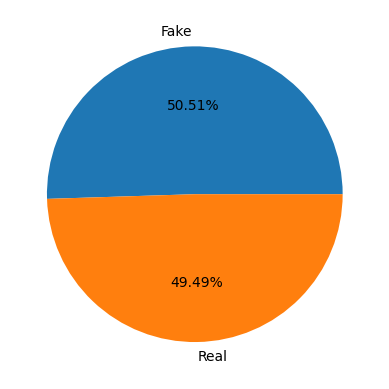

In [19]:
plt.pie(labels.value_counts(), 
        labels=labels.value_counts().index, autopct='%2.2f%%');

#### Data Preparation

##### Data Cleaning

In [22]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [23]:
sent = 'Hello friends! How are you? I like Python programming.'

In [24]:
tokens1 = word_tokenize(sent)
tokens1

['Hello',
 'friends',
 '!',
 'How',
 'are',
 'you',
 '?',
 'I',
 'like',
 'Python',
 'programming',
 '.']

In [25]:
# keep only the alphabets 
tokens2 = [x for x in tokens1 if x.isalpha()]

In [26]:
tokens2

['Hello', 'friends', 'How', 'are', 'you', 'I', 'like', 'Python', 'programming']

In [27]:
# remove stopwords 
swords = stopwords.words('english')

In [28]:
swords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [31]:
tokens3 = [x.lower() for x in tokens2 if x.lower() not in swords]

In [32]:
tokens3

['hello', 'friends', 'like', 'python', 'programming']

In [36]:
# apply the stemming
ps = PorterStemmer()

In [37]:
tokens4 = [ps.stem(x) for x in tokens3]

In [35]:
tokens4

['hello', 'friend', 'like', 'python', 'program']

In [38]:
def clean_text(sent):
    tokens1 = word_tokenize(sent)
    tokens2 = [x for x in tokens1 if x.isalpha()]
    tokens3 = [x.lower() for x in tokens2 if x.lower() not in swords]
    tokens4 = [ps.stem(x) for x in tokens3]
    return tokens4

In [40]:
sent

'Hello friends! How are you? I like Python programming.'

In [39]:
clean_text(sent)

['hello', 'friend', 'like', 'python', 'program']

In [43]:
new_sent = 'It was expected result. They told me the same on fields.'

In [44]:
clean_text(new_sent)

['expect', 'result', 'told', 'field']

In [46]:
clean_text(features[100])

['departur',
 'commun',
 'aid',
 'could',
 'first',
 'trump',
 'washington',
 'reuter',
 'presid',
 'donald',
 'trump',
 'commun',
 'director',
 'leav',
 'job',
 'white',
 'hous',
 'said',
 'tuesday',
 'presid',
 'consid',
 'wider',
 'staff',
 'chang',
 'tri',
 'contain',
 'polit',
 'damag',
 'investig',
 'russia',
 'presidenti',
 'campaign',
 'mike',
 'dubk',
 'confirm',
 'report',
 'resign',
 'say',
 'statement',
 'great',
 'honor',
 'serv',
 'presid',
 'trump',
 'dubk',
 'job',
 'three',
 'month',
 'gave',
 'reason',
 'leav',
 'trump',
 'return',
 'washington',
 'saturday',
 'trip',
 'middl',
 'east',
 'europ',
 'expect',
 'shake',
 'staff',
 'tackl',
 'firestorm',
 'investig',
 'alleg',
 'russian',
 'meddl',
 'presidenti',
 'elect',
 'commun',
 'russia',
 'trump',
 'campaign',
 'transit',
 'team',
 'trump',
 'plan',
 'bring',
 'new',
 'aid',
 'white',
 'hous',
 'ad',
 'experienc',
 'polit',
 'profession',
 'includ',
 'former',
 'campaign',
 'manag',
 'accord',
 'administr',
 'offic

##### TF*IDF Vectorization

In [49]:
# import the class 
from sklearn.feature_extraction.text import TfidfVectorizer

In [50]:
# create the object 
tfidf = TfidfVectorizer(analyzer=clean_text)

In [51]:
# apply the method 
features_new = tfidf.fit_transform(features)

In [52]:
features_new.shape

(9900, 33562)

In [53]:
tfidf.get_feature_names_out()

array(['aaa', 'aaaaackkk', 'aaaarrgh', ..., 'zzzzzzzzzzzzz', 'émigré',
       'ツ'], dtype=object)

In [54]:
len(tfidf.get_feature_names_out())

33562

In [55]:
features_new.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

#### Cross Validation

In [57]:
# import the function
from sklearn.model_selection import train_test_split

In [58]:
# split the data -> 75% in training and 25% in testing
x_train, x_test, y_train, y_test = train_test_split(
    features_new, labels, random_state=0
)

In [59]:
x_train.shape

(7425, 33562)

In [60]:
x_test.shape

(2475, 33562)

#### Build the model